In [4]:
import bayesian_optimization as bo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.special import comb
from scipy.stats import norm
import seaborn as sns
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel,
)
sns.set()

[[0 1]
 [0 1]]
[[0.         0.        ]
 [0.01010101 0.        ]
 [0.02020202 0.        ]
 ...
 [0.97979798 1.        ]
 [0.98989899 1.        ]
 [1.         1.        ]]


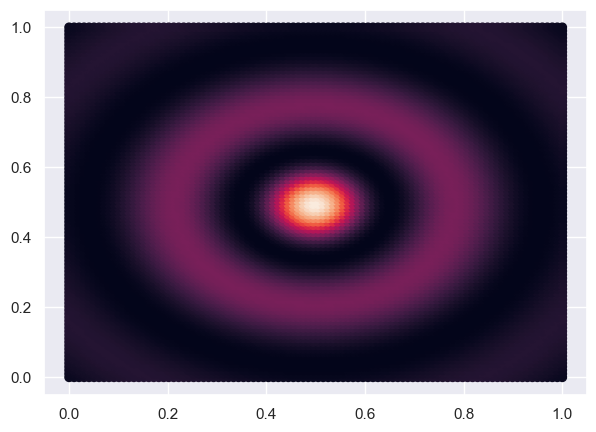

In [5]:
# set up true objective
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def f1(x):
    """
    Drop-Wave function on [0, 1]², vectorised.

    Input
    -----
    x : array_like
        Shape (2,)  – a single point
        Shape (N,2) – N points
        Each coordinate must lie in [0, 1].

    Output
    ------
    float or ndarray
        Scalar if the input is shape (2,); 1-D array of length N if (N,2).
    """
    x = np.asarray(x, dtype=float)

    # --- rescale from [0,1] to the classical domain [-5.12, 5.12] ---
    u0 = 10.24 * x[..., 0] - 5.12
    u1 = 10.24 * x[..., 1] - 5.12

    # --- Drop-Wave formula ---
    r2 = u0**2 + u1**2               # squared radius
    r  = np.sqrt(r2)                 # radius
    value = -(1 + np.cos(2 * r)) / (0.5 * r2 + 2)

    return -2*value

bounds = np.asarray(((0, 1),(0,1)))
print(bounds)
#x_star = np.linspace(*bounds, 10000)
n_points = 100
# Create a vector for each coordinate axis
x1s = np.linspace(bounds[0][0], bounds[0][1], n_points)
x2s = np.linspace(bounds[1][0], bounds[1][1], n_points)
# Form a mesh grid, then flatten to (N, 2)
X1, X2 = np.meshgrid(x1s, x2s)                 # each is (n_points, n_points)
x_star = np.column_stack([X1.ravel(), X2.ravel()])

print(x_star)
f_star = f1(x_star)
true_max = np.max(f_star)
true_max_location = x_star[np.argmax(f_star)]

plt.figure(figsize=(7,5))
#plt.plot(x_star, f_star)
plt.scatter(x_star[:,0],x_star[:,1],c=f_star)

In [6]:
true_max

1.9866635692942436

In [ ]:
# define kenel
dim = 2
kern_signal = C(1.0, (1e-3, 1e3)) * Matern(
            length_scale=np.ones(dim),
            length_scale_bounds=(1e-3, 1e3),
            nu=2.5,
        )
kern_noise = WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(1e-3, 1),
    )
kernel=kern_signal + kern_noise

# create starting data
std_noise = 0.01
np.random.seed(42)
n_init = 5
x_init = np.random.uniform(low=bounds[:,0], high=bounds[:,1], size=(n_init,dim))
#x_init = np.linspace(bounds[0], bounds[1],n_init)
#x_init = np.linspace(bounds[0], 1.25, 5)
print(x_init)
y_init = f1(x_init) + np.random.normal(0, std_noise, size=n_init)

# optimizer parameter -linear increase
n_iter = 25
g = 1
alpha_low = 0.1
acq_samples = dim*10
optimizer = bo.BayesianOptimizer(
    func = f1,
    kernel = kernel,
    bounds = np.array(bounds).reshape(dim, 2),
    g= np.ones(n_iter)*g,
    alpha = np.linspace(alpha_low, 1.0, n_iter),
    x_init = x_init.reshape(-1,dim),
    y_init = y_init.reshape(-1,1),
    xi = 0,
    n_iter= n_iter,
    acq_samples=acq_samples, # num starting points to optimize acquization
    random_state=42,

)

# run optimization
opt_result = optimizer.simulate_optimization(noise_std = std_noise, max_val=true_max, visualize=False, verbose= False)
print(opt_result)
linear_alpha_result = {"cumulative_regrets": np.sum(opt_result["inst_regrets"]),  "dataset_x": optimizer.X, "dataset_y": optimizer.Y, **opt_result}
alpha_result = {"linear_increase":linear_alpha_result}

[[0.37454012 0.95071431]
 [0.73199394 0.59865848]
 [0.15601864 0.15599452]
 [0.05808361 0.86617615]
 [0.60111501 0.70807258]]


100%|██████████| 25/25 [00:04<00:00,  6.15it/s]

{'best_iteration_observed': 9, 'best_observed': 0.6148383706850511, 'best_observed_x': array([0.75236488, 0.62452815]), 'best_iteration_regret': 9, 'inst_regrets': array([1.37993225, 1.95184796, 1.80504715, 1.43122113, 1.84763277,
       1.89554179, 1.63002999, 1.98526451, 1.42847571, 1.37941489,
       1.98620729, 1.48553034, 1.5066796 , 1.44595108, 1.38189477,
       1.54967208, 1.92889094, 1.97179589, 1.49052143, 1.38765446,
       1.50906383, 1.97957011, 1.86137853, 1.53518577, 1.39430394])}


In [10]:
# linear decrease g
g_max = 3
optimizer = bo.BayesianOptimizer(
    func = f1,
    kernel = kernel,
    bounds = np.array(bounds).reshape(dim, 2),
    g= np.linspace(g_max, 0, n_iter),
    alpha = np.ones(n_iter),
    x_init = x_init.reshape(-1,dim),
    y_init = y_init.reshape(-1,1),
    xi = 0,
    n_iter= n_iter,
    acq_samples=5, # num starting points to optimize acquization
    random_state=42,

)

# run optimization
opt_result = optimizer.simulate_optimization(noise_std = std_noise, max_val=true_max, visualize=False, verbose= False)
print(opt_result)
linear_g_result = {"cumulative_regrets": np.sum(opt_result["inst_regrets"]),  "dataset_x": optimizer.X, "dataset_y": optimizer.Y, **opt_result}
g_result["linear_decay"] = linear_g_result

100%|██████████| 25/25 [00:48<00:00,  1.95s/it]

{'best_iteration_observed': 24, 'best_observed': 0.6064318061596612, 'best_observed_x': array([0.40288243, 0.77718028]), 'best_iteration_regret': 0, 'inst_regrets': array([1.37993225, 1.94215616, 1.88847558, 1.95365974, 1.94490738,
       1.97598115, 1.48458329, 1.95558649, 1.94216291, 1.97284373,
       1.92179259, 1.44668808, 1.41789804, 1.67366594, 1.42698074,
       1.38523748, 1.58210146, 1.95507208, 1.70306995, 1.39783062,
       1.41865592, 1.39419213, 1.5436918 , 1.7772431 , 1.38436611])}


NameError: name 'g_result' is not defined

In [ ]:
 #RUN FOR ALL gs
all_gs = np.arange(0, 3.5, 0.5)
for g in all_gs:
    optimizer = bo.BayesianOptimizer(
        func = f1,
        kernel = kernel,
        bounds = np.array(bounds).reshape(dim, 2),
        g= np.ones(n_iter)*g,
        alpha = np.ones(n_iter),
        x_init = x_init.reshape(-1,dim),
        y_init = y_init.reshape(-1,1),
        xi = 0,
        n_iter= n_iter,
        acq_samples=acq_samples, # num starting points to optimize acquization
        random_state=42
    )
    opt_result = optimizer.simulate_optimization(noise_std = std_noise, max_val=true_max, verbose= False)
    print(opt_result)
    temp_result = {"cumulative_regrets": np.sum(opt_result["inst_regrets"]),  "dataset_x": optimizer.X, "dataset_y": optimizer.Y, **opt_result}
    g_result[g] = temp_result
    # visualize
    fig, (ax_f, ax_mu) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    # ---------- left panel: true objective f_star ----------
    sc_f = ax_f.scatter(
            x_star[:, 0], x_star[:, 1],
            c=f_star.ravel(), cmap='viridis', alpha=0.5, label='true f(x)'
    )
    data_x, data_y = optimizer.X[n_init:], optimizer.Y[n_init:]
    ax_f.scatter(
            data_x[:, 0], data_x[:, 1],
            c=data_y.ravel(), cmap='viridis', edgecolor='k', s=50
    )

    for i, (pt, label) in enumerate(zip(data_x, data_y)):
        ax_f.text(pt[0], pt[1], str(i),
                color='black', fontsize=9,
                ha='center', va='bottom')

    ax_f.set_title("True function $f(x)$")
    ax_f.set_xlabel(r"$x_0$")
    ax_f.set_ylabel(r"$x_1$")
    fig.colorbar(sc_f, ax=ax_f, label='f value')

    # ---------- right panel: GP mean μ ----------
    mu, std = optimizer.predict_tempered(x_star, 1)   # x_star already (N,2)

    sc_mu = ax_mu.scatter(
            x_star[:, 0], x_star[:, 1],
            c=mu.ravel(), cmap='plasma', alpha=0.5, label='GP mean', zorder=-1
    )
    ax_mu.scatter(
            data_x[:, 0], data_x[:, 1],
            c=data_y.ravel(), cmap='plasma', edgecolor='k', s=50
    )

    ax_mu.set_title(r"GP mean $\mu(x)$ (g = {})".format(g))
    ax_mu.set_xlabel(r"$x_0$")
    # y-label shared, so only set on the first axis
    fig.colorbar(sc_mu, ax=ax_mu, label='μ value')

    plt.tight_layout()
    plt.show()

In [ ]:
cols = ['cumulative_regrets', 'best_iteration_observed', 'best_observed', 'best_observed_x', 'best_iteration_regret']
g_result_df = pd.DataFrame({
    key: {c: sub.get(c, None) for c in cols}
    for key, sub in g_result.items()
}).T

In [ ]:
g_result_df

In [ ]:
import numpy as np
import pandas as pd
import bayesian_optimization as bo   # your BayesianOptimizer

# ------------------------------------------------------------------
# CONSTANTS & helpers (unchanged)
# ------------------------------------------------------------------
dim, n_init, n_iter, acq_samples = 2, 5, 25, 10
bounds        = ((0, 1), (0, 1))
std_noise     = 0.01
true_max      = 2.
all_alphas    = np.append(np.arange(0.1, 1.1, 0.1), 0.01)
seeds         = range(10)

def build_alpha_schedule(kind: str, const_val: float | None = None,
                         n_steps: int = n_iter) -> np.ndarray:
    if kind == "constant":
        if const_val is None:
            raise ValueError("const_val required for constant schedule")
        return np.full(n_steps, const_val, dtype=float)
    elif kind == "linear_increase":
        return np.linspace(0.01, 1.0, n_steps, dtype=float)
    elif kind == "linear_decay":
        return np.linspace(1.0, 0.01, n_steps, dtype=float)
    else:
        raise ValueError(f"unknown schedule '{kind}'")

# ------------------------------------------------------------------
# MAIN LOOP: sweep g × seeds × schedules × (constant-α values)
# ------------------------------------------------------------------
records = []

all_gs = np.arange(0.0, 3.5, 0.5)          # 0.0, 0.5, …, 3.0
for g_val in all_gs:
    for seed in seeds:
        rng = np.random.default_rng(seed)

        # random initial design per seed
        x_init = rng.uniform(low=np.array(bounds)[:, 0],
                             high=np.array(bounds)[:, 1],
                             size=(n_init, dim))
        y_init = f1(x_init).reshape(-1, 1)

        # ---------- 1) constant-α runs ----------
        for alpha_const in all_alphas:
            alpha_vec = build_alpha_schedule("constant", const_val=alpha_const)
            g_vec     = np.full(n_iter, g_val)

            optimizer = bo.BayesianOptimizer(
                func=f1, kernel=kernel,
                bounds=np.asarray(bounds).reshape(dim, 2),
                g=g_vec,
                alpha=alpha_vec,
                x_init=x_init, y_init=y_init,
                xi=0, n_iter=n_iter,
                acq_samples=acq_samples,
                random_state=seed,
            )
            res = optimizer.simulate_optimization(
                noise_std=std_noise, max_val=true_max, verbose=False
            )

            records.append({
                "seed":   seed,
                "g_param": g_val,
                "schedule": "constant",
                "alpha_param": alpha_const,
                "cumulative_regrets": res["inst_regrets"].sum(),
                "best_iteration_observed": res["best_iteration_observed"],
                "best_observed": res["best_observed"],
                "best_observed_x": res["best_observed_x"],
                "best_iteration_regret": res["best_iteration_regret"],
            })

        # ---------- 2) linear schedules ----------
        for sched_name in ["linear_increase", "linear_decay"]:
            alpha_vec = build_alpha_schedule(sched_name)
            g_vec     = np.full(n_iter, g_val)

            optimizer = bo.BayesianOptimizer(
                func=f1, kernel=kernel,
                bounds=np.asarray(bounds).reshape(dim, 2),
                g=g_vec,
                alpha=alpha_vec,
                x_init=x_init, y_init=y_init,
                xi=0, n_iter=n_iter,
                acq_samples=acq_samples,
                random_state=seed,
            )
            res = optimizer.simulate_optimization(
                noise_std=std_noise, max_val=true_max, verbose=False
            )

            records.append({
                "seed":   seed,
                "g_param": g_val,
                "schedule": sched_name,
                "alpha_param": None,
                "cumulative_regrets": res["inst_regrets"].sum(),
                "best_iteration_observed": res["best_iteration_observed"],
                "best_observed": res["best_observed"],
                "best_observed_x": res["best_observed_x"],
                "best_iteration_regret": res["best_iteration_regret"],
            })

# ------------------------------------------------------------------
# FINAL TIDY TABLE
# ------------------------------------------------------------------
results_df = pd.DataFrame.from_records(records)
# e.g. results_df.to_csv("alpha_g_sweep_results.csv", index=False)


In [ ]:
results_df.to_csv("alpha_g_sweep_results.csv", index=False)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1 · Load the results  (⇐ point to the new file)
# ------------------------------------------------------------------
df = pd.read_csv("alpha_g_sweep_results.csv")   # <<-- updated filename

# ------------------------------------------------------------------
# 2 · Build a pretty x-axis label for each run  (unchanged)
# ------------------------------------------------------------------
def make_label(row):
    if row["schedule"] == "constant":
        return f"α={row['alpha_param']:.2g}"
    return row["schedule"]

df["label"] = df.apply(make_label, axis=1)

alpha_vals = sorted(df.loc[df["schedule"] == "constant", "alpha_param"].unique())
cat_order  = [f"α={a:.2g}" for a in alpha_vals]
cat_order += [s for s in ["linear_increase", "linear_decay",
                          "linear_increase2", "linear_decay2"]
              if s in df["schedule"].unique()]
df["label"] = pd.Categorical(df["label"], categories=cat_order, ordered=True)

x_lookup = {lab: i for i, lab in enumerate(cat_order)}
df["x"]  = df["label"].map(x_lookup)

# ------------------------------------------------------------------
# 3 · Colour map for g
# ------------------------------------------------------------------
norm = plt.Normalize(df["g_param"].min(), df["g_param"].max())  # 0.0 … 3.0
cmap = plt.cm.viridis

# ------------------------------------------------------------------
# 4 · Two vertically stacked scatter panels
# ------------------------------------------------------------------
fig, (ax_reg, ax_best) = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 8), sharex=True
)

# --- panel 1: cumulative regret ---
sc1 = ax_reg.scatter(
        df["x"], df["cumulative_regrets"],
        c=df["g_param"], cmap=cmap, norm=norm,
        s=40, alpha=0.8
)
ax_reg.set_ylabel("Cumulative regret")

# --- panel 2: best observed value ---
sc2 = ax_best.scatter(
        df["x"], df["best_observed"],
        c=df["g_param"], cmap=cmap, norm=norm,
        s=40, alpha=0.8
)
ax_best.set_ylabel("Best observed value")

# --- common x-axis cosmetics ---
ax_best.set_xticks(range(len(cat_order)))
ax_best.set_xticklabels(cat_order, rotation=45, ha="right")
ax_best.set_xlabel("Schedule / constant α")

# --- one shared colour-bar for g ---
cbar = fig.colorbar(sc1, ax=[ax_reg, ax_best], label="g value")

#fig.tight_layout()
plt.show()
